# Validation of scenario reproduction

The ATAG Waypoint reports are dense and information-heavy, meaning many assumptions are explicit and quantified in the report itself. However, for scenario reproduction purposes with AeroMAPS, we may either try to approximate results by tweaking parameters, or directly feed on report data.

We'll start by importing necessary libraries and functions. Then AeroMAPS processes are created and assembled into traffic variants and technology variants.

In [1]:
%matplotlib widget

import gemseo as gm
import numpy as np
import matplotlib.pyplot as plt

from aeromaps import create_process, assemble_processes
from aeromaps.utils.functions import custom_logger_config

from scipy.interpolate import interp1d

custom_logger_config(gm.configure_logger())

high_years = [2021.7051263083038,2022.8850697046203,2024.329179532948,2025.7732893612756,2027.2173991896032,2028.6615090179307,2030.1056188462585,2031.549728674586,2032.9938385029136,2034.4379483312412,2035.882058159569,2037.3261679878965,2038.770277816224,2040.2143876445516,2041.6584974728794,2043.102607301207,2044.5467171295345,2045.990826957862,2047.4349367861898,2048.8790466145174,2050.3055453473776]
high_rpk = [6.011488693330836,8.455386604768744,9.768581755062456,10.514036247564519,11.233541374821247,11.96326897929584,12.683560450953948,13.393629445394204,14.091903273813855,14.795681513043125,15.509682229490242,16.255923066393677,17.034404023753424,17.866356400406566,18.750207507550364,19.650571847123,20.602834917186286,21.60306499573335,22.65519380477107,23.760007688700814,24.73158513377658]

central_years = [2020.806960439466,2022.1630147904566,2023.519069141447,2024.9631789697746,2026.4072887981024,2027.85139862643,2029.2955084547575,2030.739618283085,2032.1837281114128,2033.6278379397404,2035.071947768068,2036.5160575963955,2037.9601674247233,2039.4042772530509,2040.8483870813784,2042.292496909706,2043.7366067380337,2045.1807165663613,2046.6248263946889,2048.0689362230164,2049.513046051344,2050.6225450657907]
central_rpk = [3.5446658181913477,6.606690917139687,8.43651433913578,9.364400732756486,10.170403744164304,10.910353825856749,11.612559376283272,12.280952117450731,12.921036460168743,13.54382122605654,14.16110158113472,14.78310000262114,15.423184345339163,16.085286331295634,16.832313512600443,17.577768005102502,18.343667452040272,19.15438852985633,20.008358549747932,20.897714067701337,21.846045415757757,22.25524341389038]

low_years = [2020.9478492032051,2022.391959031533,2023.8360688598605,2025.280178688188,2026.7242885165158,2028.1683983448434,2029.612508173171,2031.0566180014985,2032.5007278298262,2033.9448376581538,2035.3889474864814,2036.833057314809,2038.2771671431367,2039.7212769714642,2041.1653867997918,2042.6094966281194,2044.0536064564471,2045.4977162847747,2046.9418261131023,2048.38593594143,2049.8300457697574,2050.781044924998]
low_rpk = [3.077577243775501,4.453679946179097,5.38313902860255,6.279571646168318,7.2011672845780375,8.09445452453831,8.877653548306302,9.5421145674669,10.098846403639318,10.565148633653795,10.95753448993916,11.300380648938003,11.610200343079143,11.918447348417555,12.448443474943282,12.821957065595683,13.208052166670065,13.630319110207623,14.084826174201499,14.56292357023657,15.051210090501456,15.200828423588145]


atag_historical_emissions = (
    [2005, 2006.9747901943263, 2008.9915965533517, 2010.966386747678, 2013.0672270389155, 2015.084035000755, 2016.9747912628688, 2019, 2020],
    [642.3290863154931, 665.4344465961955, 628.4659054030534, 674.6766259644583, 702.4026352295188, 771.7187160716262, 859.5195082100781, 905.730228771483, 452.02914273932373],
)
atag_scenario_emissions = {
    "T1": (
        [2020.5631151566047,2022.1387700782134,2023.9507732380634,2025.9597332631145,2027.9686932881655,2029.9776533132165,2031.9866133382677,2033.9955733633187,2036.3999130313196,2038.3420957608148,2040.3530728677692,2042.364049974724,2044.3750270816784,2046.386004188633,2048.3969812955875,2050.0136491658845],
        [523.0134742528617,817.8424772085145,960.6458853922247,1061.9563774923906,1151.6811716395514,1232.4377773712379,1299.4202755365739,1360.0950048163852,1434.139065922124,1489.1694418952197,1559.0207092590224,1634.2781557922594,1716.6151226664224,1809.0779489373035,1910.6797923755616,1997.159807460927],
    ),
    "T2": (
        [2020.5631151566047,2022.1387700782134,2023.9507732380634,2025.9597332631145,2027.9686932881655,2029.9776533132165,2031.9866133382677,2033.9955733633187,2041.1503469096945,2043.0343756770421,2045.0453527839966,2047.0563298909512,2049.0673069979057,2050.3488120170437],
        [523.0134742528617,817.8424772085145,960.6458853922247,1061.9563774923906,1151.6811716395514,1232.4377773712379,1299.4202755365739,1360.0950048163852,1537.552966424764,1577.8565239842735,1626.6408550608362,1682.7621435816309,1748.9885427546255,1792.8883288620525],
    ),
    "T3": (
        [2020.5631151566047,2022.1387700782134,2023.9507732380634,2025.9597332631145,2027.9686932881655,2029.9776533132165,2031.9866133382677,2033.9955733633187,2038.0326487294376,2039.9587636311117,2041.969740738066,2043.9807178450208,2045.9916949519752,2048.00267205893,2049.8164945475555],
        [523.0134742528617,817.8424772085145,960.6458853922247,1061.9563774923906,1151.6811716395514,1232.4377773712379,1299.4202755365739,1360.0950048163852,1459.9745819912696,1497.8364910398686,1539.4983955916202,1582.7049227632108,1632.0470342302706,1687.267292889493,1743.6808360636712],
    ),
    "T4": (
        [2020.5631151566047,2022.1387700782134,2023.9507732380634,2025.9597332631145,2027.9686932881655,2029.9776533132165,2031.9866133382677,2033.9955733633187,2034.6849223915224,2038.226206827838,2040.219410303673,2042.228370328724,2044.2373303537752,2046.2462903788262,2048.255250403877,2049.9293837580863],
        [523.0134742528617,817.8424772085145,960.6458853922247,1061.9563774923906,1151.6811716395514,1232.4377773712379,1299.4202755365739,1360.0950048163852,1366.6173236640032,1451.9944773793172,1478.6553138688032,1496.291320752822,1512.6829378567031,1526.9290553396575,1534.9532239219232,1535.0100390210903],
    ),
    "T5": (
        [2020.5631151566047,2022.1387700782134,2023.9507732380634,2025.9597332631145,2027.9686932881655,2029.9776533132165,2031.9866133382677,2033.9955733633187,2036.0045333883697,2038.0134934134207,2040.022453438472,2042.031413463523,2044.040373488574,2046.049333513625,2048.058293538676,2049.8309053254857,],
        [523.0134742528617,817.8424772085145,960.6458853922247,1061.9563774923906,1151.6811716395514,1232.4377773712379,1299.4202755365739,1360.0950048163852,1408.3258362948209,1430.982312291808,1428.2360727770217,1398.4994480309758,1363.141614278101,1331.1736699262913,1305.084394535821,1286.2532121804247],
    ),
}

## Traffic forecasts

As Air Traffic is the main driver for growth in aviation emissions, the forecasts for demand growth are an essential input to the Waypoint Scenarios.

We extract the Compound Annual Growth Rates (CAGR) relative to Revenue Passenger Kilometers (RPK) shown using data extraction from images.

Then we'll directly compare the RPK values from AeroMAPS with report data.

    INFO - 11:57:57: Computing scenario: Low growth
    INFO - 11:57:57: Running MDA
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
In

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:140: UserWarning: 
[Interpolation Model: atj_waste_gas_mean_mfsp_without_resource Warning]
The first reference year (2025) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:140: UserWarning: 
[Interpolation Model: electrofuel_mean_mfsp_without_resource Warning]
The first reference year (2025) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
    INFO - 11:57:59: Computing scenario: Central forecast
    INFO - 11:57:59: Running MDA
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospecti

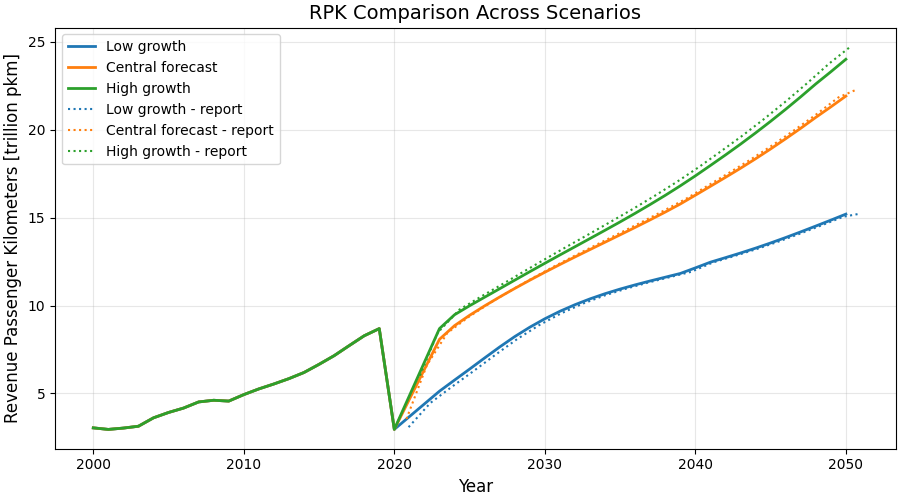

In [2]:
traffic_variants = assemble_processes({
    "Low growth": create_process(configuration_file="config_files/config_s1-low.yaml"),
    "Central forecast": create_process(configuration_file="config_files/config_s1.yaml"),
    "High growth": create_process(configuration_file="config_files/config_s1-high.yaml"),
})
traffic_variants.compute_all()

plot_rpk = traffic_variants.plot("rpk_comparison")
plot_rpk.ax.plot(low_years, low_rpk, ":", label="Low growth - report")
plot_rpk.ax.plot(central_years, central_rpk, ":", label="Central forecast - report")
plot_rpk.ax.plot(high_years, high_rpk, ":", label="High growth - report")
plot_rpk.ax.legend()

## Technology

Aircraft technology has significant improved since the commercialization of air travel, and efficiency gains have had a significant impact in reducing associated emissions.

Looking ahead, aircraft technology may continue with ever-modest efficiency gains, or adhere to disruptive technologies. We extract the CO2 emissions trajectory of 5 technological scenarios and fit annual efficiency gains based on these curbs.

    INFO - 11:58:16: Computing scenario: T1
    INFO - 11:58:16: Running MDA
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolat

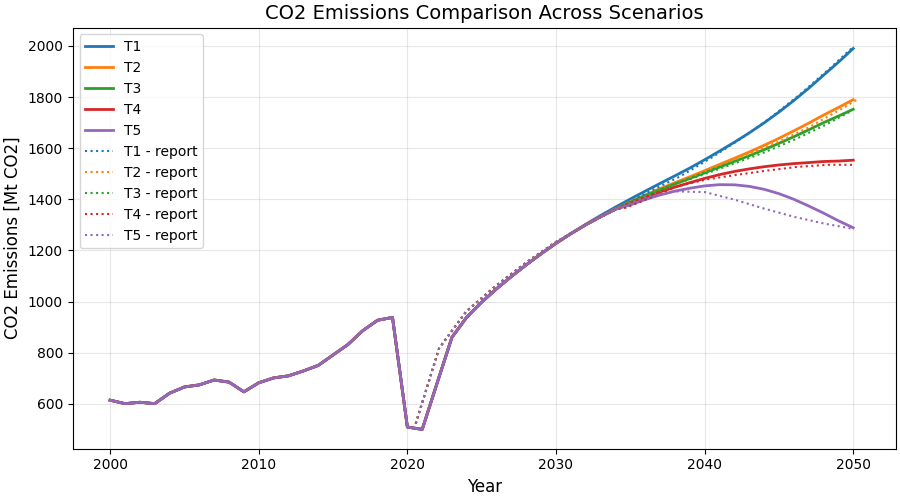

In [4]:
tech_variants = assemble_processes({
    f"T{i+1}": create_process(configuration_file=f"config_files/config_t{i+1}-TTW.yaml")
    for i in range(5)
})
tech_variants.compute_all()

plot_co2 = tech_variants.plot("co2_emissions_comparison")
for i, process in enumerate(tech_variants):
    scenario_name = tech_variants.get_scenario_names()[i]
    plot_co2.ax.plot(
        atag_scenario_emissions[scenario_name][0],
        atag_scenario_emissions[scenario_name][1],
        ":", label=f"{scenario_name} - report"
    )
plot_co2.ax.legend()

In [ ]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals(), force_cleanup=False)